In [9]:
import pandas as pd
from scipy import stats
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv("./data/penguins_cleaned.csv")
df.head()

,species,island,bill_length_mm,bill_depth_mm,flipper_length_mm,body_mass_g,sex
0,Adelie,Torgersen,39.1,18.7,181,3750,male
1,Adelie,Torgersen,39.5,17.4,186,3800,female
2,Adelie,Torgersen,40.3,18.0,195,3250,female
3,Adelie,Torgersen,36.7,19.3,193,3450,female
4,Adelie,Torgersen,39.3,20.6,190,3650,male


In [10]:
df.columns

Index(['species', 'island', 'bill_length_mm', 'bill_depth_mm',
       'flipper_length_mm', 'body_mass_g', 'sex'],
      dtype='object')

In [11]:
df.corr(numeric_only=True)

,bill_length_mm,bill_depth_mm,flipper_length_mm,body_mass_g
bill_length_mm,1.000000,-0.228626,0.653096,0.589451
bill_depth_mm,-0.228626,1.000000,-0.577792,-0.472016
flipper_length_mm,0.653096,-0.577792,1.000000,0.872979
body_mass_g,0.589451,-0.472016,0.872979,1.000000


In [12]:
x_str = "body_mass_g"
y_str = "flipper_length_mm"
x = df[x_str]
y = df[y_str]
type(x)

pandas.core.series.Series

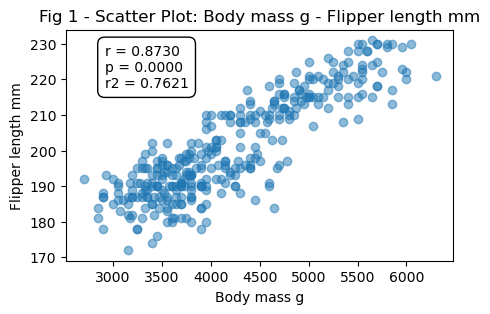

In [15]:
r, p = stats.pearsonr(x, y)
r2 = r ** 2
x_name = x_str.replace("_", " ").capitalize()
y_name = y_str.replace("_", " ").capitalize()
plt.figure(figsize=(5,3))
plt.scatter(x, y, alpha=0.5)
plt.title(f"Fig 1 - Scatter Plot: {x_name} - {y_name}")
plt.xlabel(x_name)
plt.ylabel(y_name)
text = f"""r = {r:.4f}
p = {p:.4f}
r2 = {r2:.4f}"""
plt.text(
    0.1,
    0.75,
    text,
    transform = plt.gca().transAxes,
    bbox = {"boxstyle": "round, pad = 0.5", "fc": "white"}
)
plt.show()

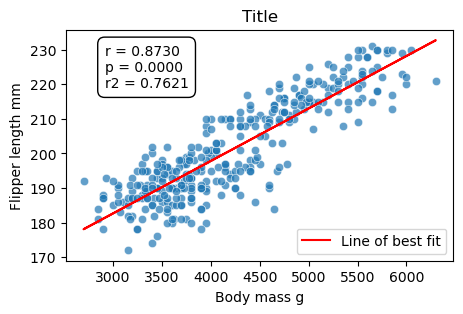

In [23]:
# Scatter with Seaborn
plt.figure(figsize=(5,3))
scat = sns.scatterplot(data = df, x = x_str, y = y_str, alpha = 0.7)
scat.set(xlabel = x_name, ylabel = y_name, title = "Title")
scat.text(
    0.1,
    0.75,
    text,
    transform = scat.transAxes,
    bbox = {"boxstyle": "round, pad = 0.5", "fc": "white"}
)
# add line of best fit
m, b, r, p ,err = stats.linregress(x, y)
line = m * x + b # -> [..,..,..,..]
plt.plot(x, line, color = "r", label = "Line of best fit")
plt.legend()
plt.show()

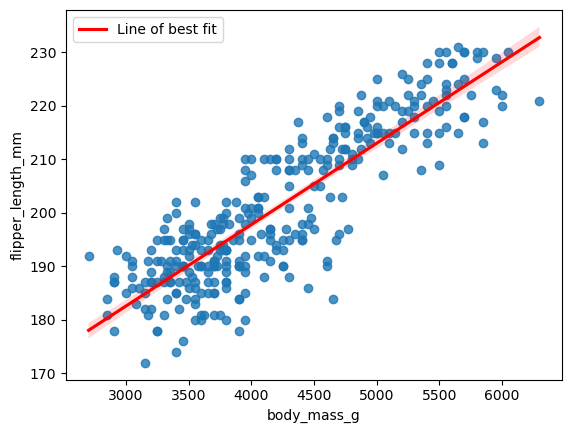

In [18]:
sns.regplot(data = df, x = x_str, y = y_str, line_kws = {"color": "red", "label": "Line of best fit"})
plt.legend()

In [24]:
species = df["species"].unique()
species

array(['Adelie', 'Gentoo', 'Chinstrap'], dtype=object)

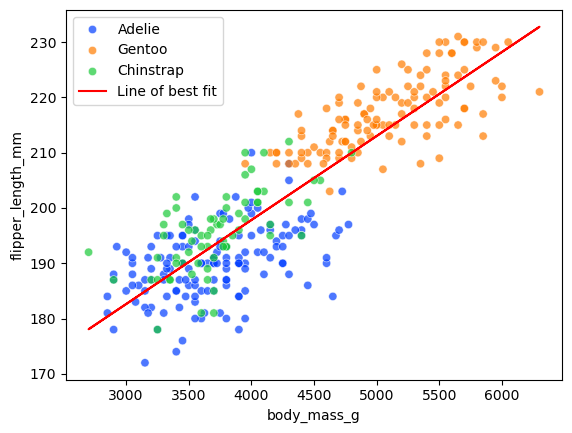

In [32]:
sns.scatterplot(data = df, x = x_str, y = y_str, hue = "species", palette = "bright", alpha = 0.7)
plt.plot(x, line, color = "r", label = "Line of best fit")
plt.legend()

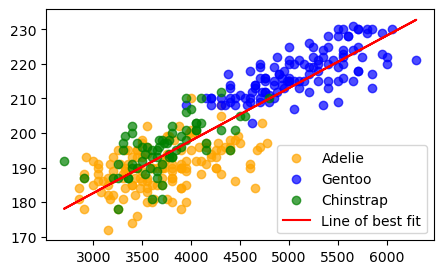

In [34]:
plt.figure(figsize=(5,3))
colors = ["orange", "blue", "green"]
for s in species:
    subset = df.loc[df["species"] == s]
    plt.scatter(subset[x_str], subset[y_str], color = colors.pop(0), label = s, alpha = 0.7)

plt.plot(x, line, color = "r", label = "Line of best fit")
plt.legend()
plt.show()

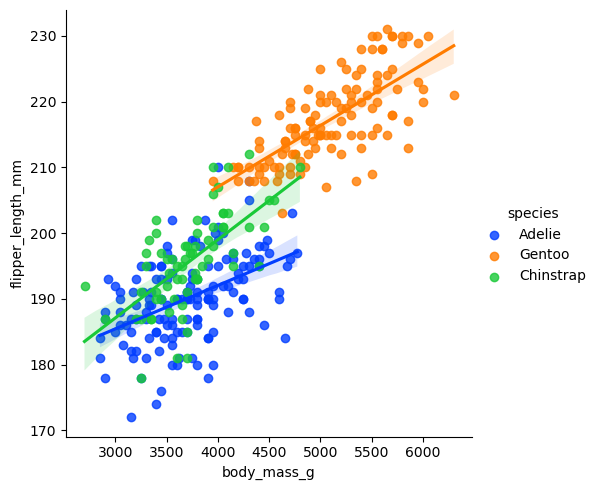

In [36]:
sns.lmplot(
    data = df,
    x = x_str,
    y = y_str,
    hue = "species",
    palette = "bright"
)

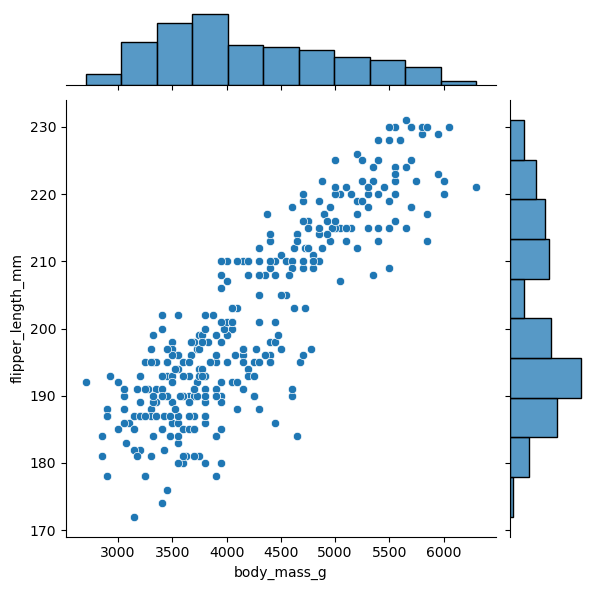

In [ ]:
sns.jointplot(data = df, x = x_str, y = y_str)

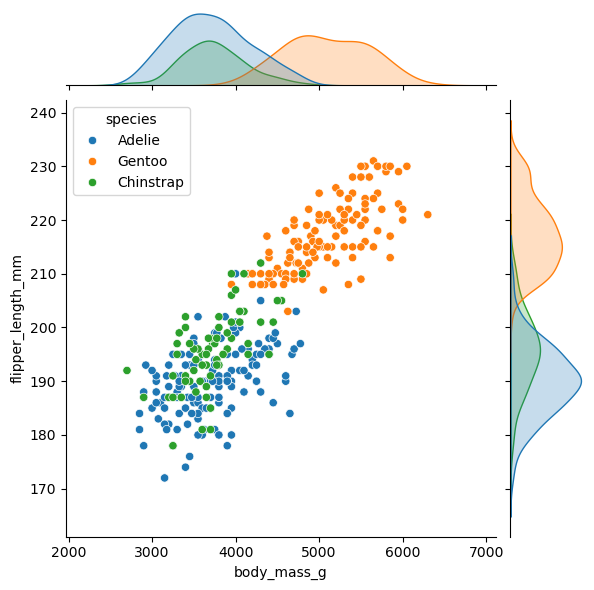

In [38]:
sns.jointplot(data = df, x = x_str, y = y_str, kind = "scatter", hue = "species")